### Assignment: 4
### Name: Se Rang Seo (Simon)
### Professor: Dr. Romanowsky


### Assignment Details:
For this assignment, you can continue with the modeling and dataset that you started in the first or second weekly assignment.  You should not use the habitable planet dataset (since we have already optimized this in class).  You may also prefer to start over with a new dataset.

Make sure to look at any instructor comments on previous work.

1. Make sure to use standard data cleaning and rescaling techniques.

2. Apply a support vector classifier to your problem.  Use your best initial ideas about the hyperparameter settings.  Report your test scores after cross-validation, and discuss the bias and variance of your model.  Try your best to visualize the classifications (both the true and the predicted labels).

3. Decide which of the three classifiers which have used so far, and which of the scoring metrics, will work best for your problem.  
Explain your reasoning.

4. Start with the chosen classifier and record the scores with vanilla/basic options as a benchmark.  Then optimize your model using hyperparameter grid-search with cross-validation.  Report the model settings and results, and again visualize the classifications.  Plot a learning curve and discuss the implications.

### ML Imports (Copy pasta)

In [1428]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics 
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC, LinearSVC # New algorithm!
from sklearn.pipeline import make_pipeline #This allows one to build different steps together
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV # New! This will be used to explore different hyperparameter choices.
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score

from scipy import stats

### Image Imports (Copy pasta)

In [1429]:
from io import StringIO  
from IPython.display import Image  
import pydotplus
from sklearn.tree import export_graphviz
import seaborn as sns

### Matplots (Copy pasta)

In [1430]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size'   : 10 } # 20}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams['figure.dpi'] = 200
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12) 
plt.rc('xtick.major', size=3, width=1.2)
plt.rc('ytick.major', size=3, width=1.2)
plt.rc('figure', figsize=[5,3])

pd.set_option('display.max_columns', 100) #These ensure that we can visualize all rows and columns in large data frames
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

### Learning Curve Plot Function

In [1431]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(5,3))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

### Confusion Matrix (Copy pasta)

In [1432]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(5,3))
    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", verticalalignment="center",
                 color="C2" if i == j else "C3", fontsize = 15)

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

### Pandas Dataset

In [1433]:
df = pd.read_csv('game.csv')

### Analyzing dataset

In [1434]:
df

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,NaN,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,NaN,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,Poor,1.62,2.0,Withdrawn,Daily,True,True,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,Average,2.44,NaN,Angry,Daily,True,False,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,Average,2.96,NaN,Restless,Sometimes,True,False,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,Excellent,3.42,NaN,Angry,Often,False,False,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,Poor,NaN,3.0,Withdrawn,Daily,True,True,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,Good,1.03,NaN,Normal,Rarely,False,False,False,False,False,0.8,8.4,1,12.7,22.02,8,Low


I'm going to drop worded columns like record_id, gender, game_genre, primary_game, gaming_platform.

I'll also drop all the NAN.

In [1435]:
df_dropped = df.drop(['record_id','gender','primary_game','game_genre','gaming_platform'], axis = 1)
df_dropped = df_dropped.dropna() # drop rows with missing values

In [1436]:
df_dropped

,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
1,21,3.0,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
3,20,7.2,5.1,Fair,Often,Poor,1.62,2.0,Withdrawn,Daily,True,True,False,True,True,0.2,5.2,4,9.1,51.60,7,High
5,21,2.1,7.5,Fair,Rarely,Good,3.81,4.0,Normal,Never,False,False,False,False,False,0.2,10.8,1,9.6,8.63,4,Low
6,21,2.7,7.2,Very Poor,Often,Below Average,1.82,6.0,Euphoric,Rarely,False,False,False,False,False,0.8,10.0,2,10.1,35.25,3,Low
13,22,5.1,5.3,Fair,Never,Average,3.25,6.0,Anxious,Rarely,False,False,False,True,False,0.9,7.6,3,6.3,36.07,5,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,22,13.6,5.8,Poor,Rarely,Failing,2.92,5.0,Irritable,Often,True,True,False,True,False,1.4,2.4,8,0.0,438.83,2,Severe
987,19,4.7,6.7,Fair,Often,Excellent,2.02,10.0,Restless,Often,False,False,False,False,False,2.9,6.5,2,9.0,59.91,9,Low
988,20,4.4,5.4,Very Poor,Sometimes,Good,2.26,5.0,Euphoric,Sometimes,False,False,False,False,False,1.0,9.7,3,12.1,8.08,7,Low
990,19,7.0,3.2,Fair,Often,Poor,3.00,1.0,Anxious,Daily,False,True,False,False,True,1.4,7.7,5,5.8,121.06,2,Moderate


### All the good, bad, poor, etc columns

In [1437]:
print("sleep quality: ",df_dropped['sleep_quality'].unique())
print("sleep disruption frequency: ",df_dropped['sleep_disruption_frequency'].unique())
print("mood state: ",df_dropped['mood_state'].unique())
print("mood swing frequency: ",df_dropped['mood_swing_frequency'].unique())
print("academic work performance: ",df_dropped['academic_work_performance'].unique())

sleep quality:  ['Fair' 'Very Poor' 'Good' 'Poor' 'Insomnia']
sleep disruption frequency:  ['Rarely' 'Often' 'Never' 'Sometimes' 'Always']
mood state:  ['Irritable' 'Withdrawn' 'Normal' 'Euphoric' 'Anxious' 'Restless' 'Angry'
 'Depressed' 'Excited']
mood swing frequency:  ['Often' 'Daily' 'Never' 'Rarely' 'Sometimes']
academic work performance:  ['Good' 'Poor' 'Below Average' 'Average' 'Excellent' 'Failing']


In [1438]:
#sleep quality
df_dropped['sleep_quality'] = df_dropped['sleep_quality'].map({
    'Fair': 3, 'Very Poor': 1, 'Good': 4, 'Poor': 2, 'Insomnia': 0
})

#sleep disruption frequency
sleep_dis = {'Rarely': 3, 'Often': 2, 'Never': 4, 'Sometimes': 1, 'Always': 0}
df_dropped['sleep_disruption_frequency'] = df_dropped['sleep_disruption_frequency'].map(sleep_dis)

# Mood state
mood_map = {'Irritable': 0, 'Withdrawn': 1,    'Normal': 2,  'Euphoric': 3,   'Anxious': 4,  'Restless': 5,
     'Angry': 6, 'Depressed': 7,   'Excited': 8}
df_dropped['mood_state'] = df_dropped['mood_state'].map(mood_map)

# Mood swing frequency
mood_fre = {'Often' : 0, 'Daily' : 1, 'Never': 4, 'Rarely' : 3, 'Sometimes' : 2}
df_dropped['mood_swing_frequency'] = df_dropped['mood_swing_frequency'].map(mood_fre)

#work_academic performance
academic_map = {'Good': 4, 'Poor': 1, 'Below Average': 2, 'Average': 3, 'Excellent': 5, 'Failing': 0}
df_dropped['academic_work_performance'] = df_dropped['academic_work_performance'].map(academic_map)


### All the true/false columns

In [1439]:
print("withdrawal symptoms: ",df_dropped['withdrawal_symptoms'].unique())
print("loss of other interests: ",df_dropped['loss_of_other_interests'].unique())
print("continued despite problems: ",df_dropped['continued_despite_problems'].unique())
print("eye strain: ",df_dropped['eye_strain'].unique())
print("back neck pain: ",df_dropped['back_neck_pain'].unique())

withdrawal symptoms:  [False  True]
loss of other interests:  [False  True]
continued despite problems:  [False  True]
eye strain:  [False  True]
back neck pain:  [False  True]


In [1440]:
#withdrawal_symptoms
df_dropped['withdrawal_symptoms'] = df_dropped['withdrawal_symptoms'].map({True: 1, False: 0})

#loss of interests
df_dropped['loss_of_other_interests'] = df_dropped['loss_of_other_interests'].map({True: 1, False: 0})

#continued despite problems
df_dropped['continued_despite_problems'] = df_dropped['continued_despite_problems'].map({True: 1, False: 0})

#eye strain
df_dropped['eye_strain'] = df_dropped['eye_strain'].map({True: 1, False: 0})

#back neck pain
df_dropped['back_neck_pain'] = df_dropped['back_neck_pain'].map({True: 1, False: 0})

In [1441]:
df_dropped

,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
1,21,3.0,7.2,3,3,4,3.75,2.0,0,0,0,0,0,0,0,0.4,8.5,2,10.7,46.64,1,Low
3,20,7.2,5.1,3,2,1,1.62,2.0,1,1,1,1,0,1,1,0.2,5.2,4,9.1,51.60,7,High
5,21,2.1,7.5,3,3,4,3.81,4.0,2,4,0,0,0,0,0,0.2,10.8,1,9.6,8.63,4,Low
6,21,2.7,7.2,1,2,2,1.82,6.0,3,3,0,0,0,0,0,0.8,10.0,2,10.1,35.25,3,Low
13,22,5.1,5.3,3,4,3,3.25,6.0,4,3,0,0,0,1,0,0.9,7.6,3,6.3,36.07,5,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,22,13.6,5.8,2,3,0,2.92,5.0,0,0,1,1,0,1,0,1.4,2.4,8,0.0,438.83,2,Severe
987,19,4.7,6.7,3,2,5,2.02,10.0,5,0,0,0,0,0,0,2.9,6.5,2,9.0,59.91,9,Low
988,20,4.4,5.4,1,1,4,2.26,5.0,3,2,0,0,0,0,0,1.0,9.7,3,12.1,8.08,7,Low
990,19,7.0,3.2,3,2,1,3.00,1.0,4,1,0,1,0,0,1,1.4,7.7,5,5.8,121.06,2,Moderate


Now that I've converted all of the features into numbers, I have to look at the target: Game Addiction Risk Level.

The problem is that this is a multi-leveled classification file: Severe, Low, Moderate, High.

In [1442]:
print("gaming_addiction_risk_level: ",df_dropped['gaming_addiction_risk_level'].unique())

gaming_addiction_risk_level:  ['Low' 'High' 'Severe' 'Moderate']


I'm going to make it binary classification by setting high and severe to be 1 and low and moderate to be 0.

In [1443]:
df_dropped['gaming_addiction_risk_level'] = df_dropped['gaming_addiction_risk_level'].map({'Severe': 1, 'High': 1, 'Low': 0, 'Moderate' : 0})

In [1444]:
final_features = df_dropped

In [1445]:
final_features

,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
1,21,3.0,7.2,3,3,4,3.75,2.0,0,0,0,0,0,0,0,0.4,8.5,2,10.7,46.64,1,0
3,20,7.2,5.1,3,2,1,1.62,2.0,1,1,1,1,0,1,1,0.2,5.2,4,9.1,51.60,7,1
5,21,2.1,7.5,3,3,4,3.81,4.0,2,4,0,0,0,0,0,0.2,10.8,1,9.6,8.63,4,0
6,21,2.7,7.2,1,2,2,1.82,6.0,3,3,0,0,0,0,0,0.8,10.0,2,10.1,35.25,3,0
13,22,5.1,5.3,3,4,3,3.25,6.0,4,3,0,0,0,1,0,0.9,7.6,3,6.3,36.07,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,22,13.6,5.8,2,3,0,2.92,5.0,0,0,1,1,0,1,0,1.4,2.4,8,0.0,438.83,2,1
987,19,4.7,6.7,3,2,5,2.02,10.0,5,0,0,0,0,0,0,2.9,6.5,2,9.0,59.91,9,0
988,20,4.4,5.4,1,1,4,2.26,5.0,3,2,0,0,0,0,0,1.0,9.7,3,12.1,8.08,7,0
990,19,7.0,3.2,3,2,1,3.00,1.0,4,1,0,1,0,0,1,1.4,7.7,5,5.8,121.06,2,0


### Plotting

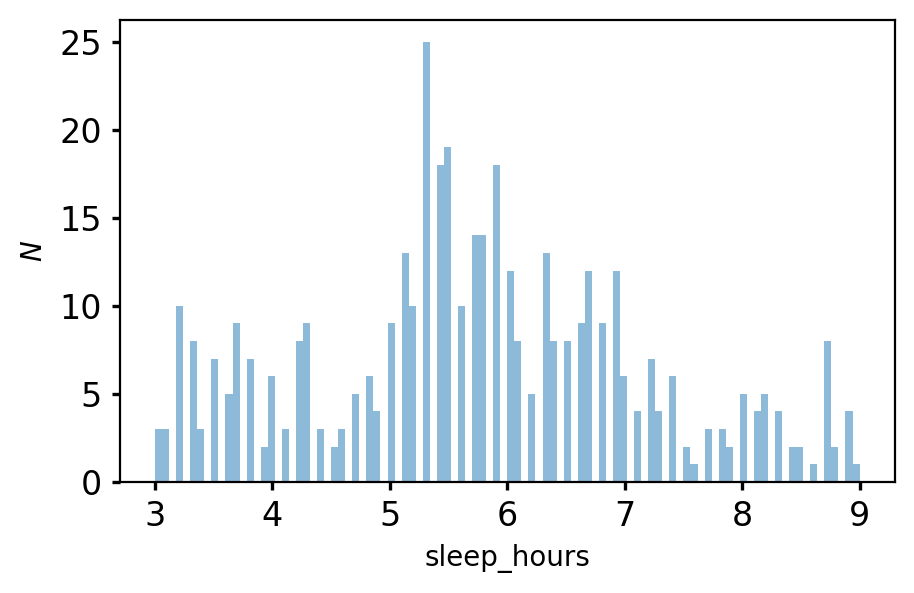

In [1446]:
fig1 = plt.figure()
plt.hist(final_features.iloc[:,2], bins = 100, alpha = 0.5)
plt.xlabel(final_features.columns[2])
plt.ylabel('$N$');

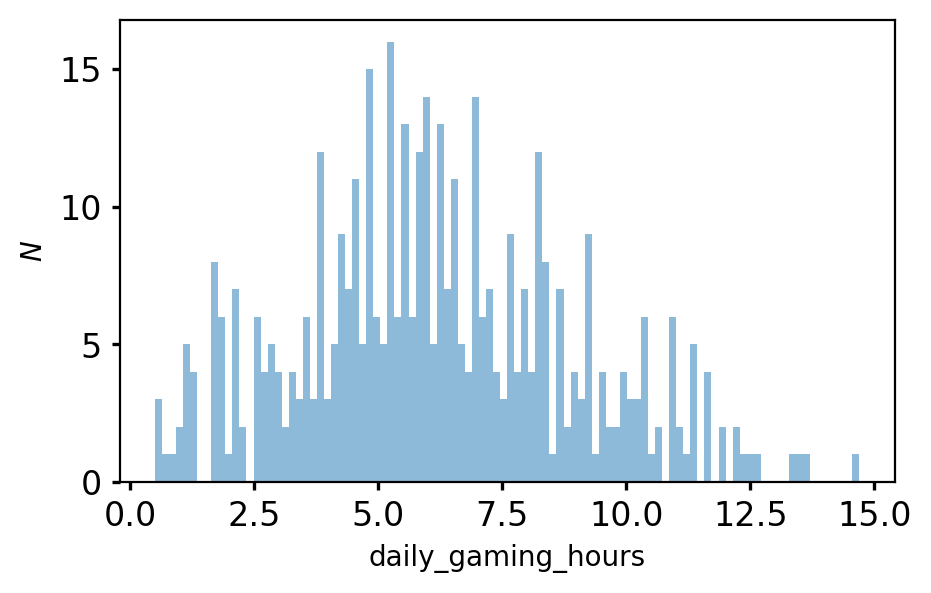

In [1447]:
fig1 = plt.figure()
plt.hist(final_features.iloc[:,1], bins = 100, alpha = 0.5)
plt.xlabel(final_features.columns[1])
plt.ylabel('$N$');

In [1448]:
final_features.describe()

,age,daily_gaming_hours,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
count,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000
mean,20.221963,6.182009,5.736215,2.436916,2.107477,2.546729,2.487710,5.427570,3.567757,2.016355,0.306075,0.338785,0.123832,0.509346,0.357477,1.471963,6.881308,3.927570,7.550701,112.010000,5.600467,0.303738
std,1.088489,2.763212,1.414154,1.113360,1.386668,1.448625,0.859132,2.886111,2.338475,1.398297,0.461400,0.473851,0.329775,0.500498,0.479818,1.349632,1.802971,2.030652,3.671081,121.846851,3.084554,0.460409
min,19.000000,0.500000,3.000000,0.000000,0.000000,0.000000,1.020000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000,1.000000,0.000000,0.440000,1.000000,0.000000
25%,19.000000,4.400000,5.000000,2.000000,1.000000,1.000000,1.760000,3.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,5.600000,2.000000,5.175000,35.250000,3.000000,0.000000
50%,20.000000,5.950000,5.700000,2.000000,2.000000,3.000000,2.465000,5.000000,4.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.100000,6.900000,4.000000,7.800000,70.610000,6.000000,0.000000
75%,21.000000,8.025000,6.700000,3.000000,3.000000,4.000000,3.242500,8.000000,5.000000,3.000000,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000,8.200000,5.000000,10.000000,124.520000,8.000000,1.000000
max,22.000000,14.700000,9.000000,4.000000,4.000000,5.000000,3.990000,10.000000,8.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.900000,11.300000,10.000000,16.700000,499.270000,12.000000,1.000000


In [1449]:
targets = df_dropped['gaming_addiction_risk_level'] 

In [1450]:
targets

1      0
3      1
5      0
6      0
13     0
      ..
981    1
987    0
988    0
990    0
994    1
Name: gaming_addiction_risk_level, Length: 428, dtype: int64

In [1451]:
#dropping outliers by dropping rows with sigma greater than 5
final_features = final_features[(np.abs(stats.zscore(final_features)) < 5).all(axis=1)]
 
targets = targets[final_features.index]

#reset index
final_features = final_features.reset_index(drop=True)

<Figure size 1000x600 with 0 Axes>

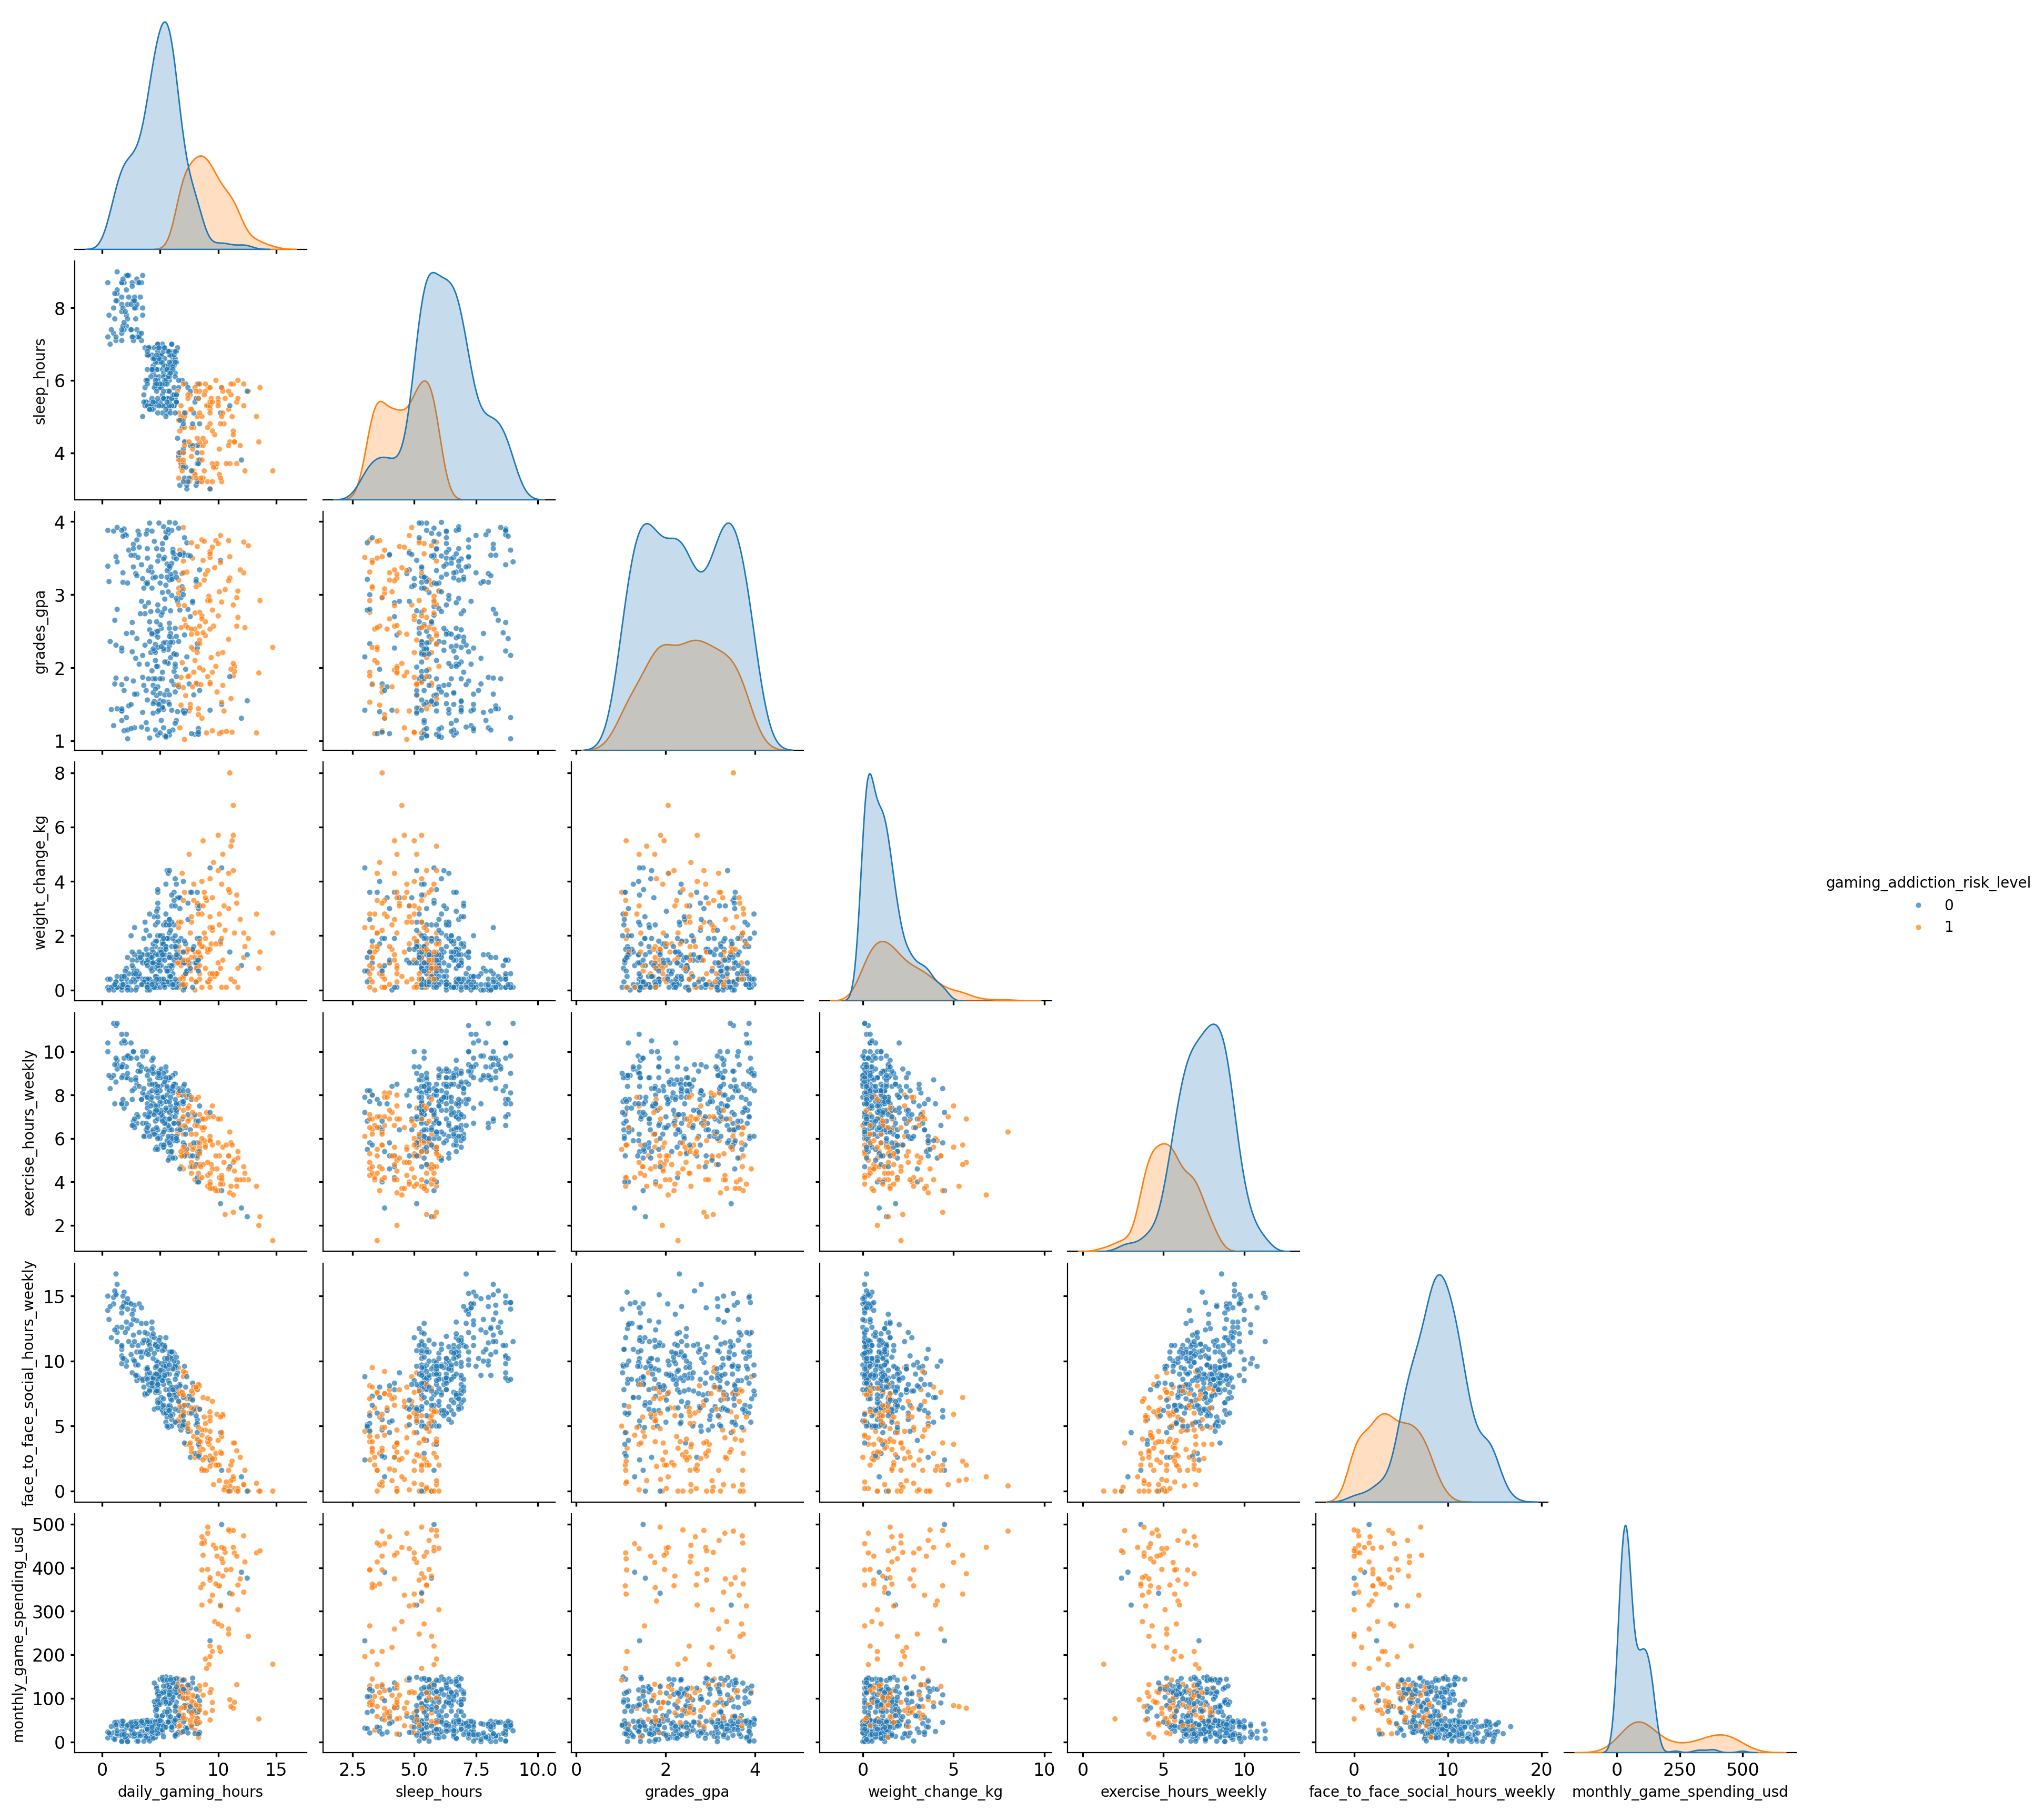

In [1452]:
# Assuming 'targets' is your target column name, it should be a string
# For example, if your target column is called 'gaming_addiction_risk_level':

target_column = 'gaming_addiction_risk_level'  # Replace with your actual target column name

fig3 = plt.figure()
p = sns.pairplot(final_features, 
                 vars=[ 'daily_gaming_hours', 'sleep_hours', 
                       'grades_gpa', 'weight_change_kg', 'exercise_hours_weekly', 
                       'face_to_face_social_hours_weekly', 'monthly_game_spending_usd',],
                 corner=True, 
                 hue=target_column,  # This should be a string, not a Series
                 plot_kws={"s": 15, "alpha": 0.7})

In [1453]:
final_features = final_features.drop('gaming_addiction_risk_level', axis = 1)

### Train and test set

In [1454]:
Xtrain, Xtest, ytrain, ytest = train_test_split(final_features, targets, random_state=2)

## Linear SVC Algorithm

In [1455]:
svc_model_linear = LinearSVC(dual = False, class_weight='balanced') #Prefer dual=False when n_samples > n_features. If not, will not converge!!
svc_model_linear.fit(Xtrain, ytrain)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo

### Scores

In [1456]:
print('train accuracy = ', metrics.accuracy_score(ytrain, svc_model_linear.predict(Xtrain))) #train score
print('test accuracy = ', metrics.accuracy_score(ytest, svc_model_linear.predict(Xtest))) #test score
print('dummy classifier =', metrics.accuracy_score(ytest, np.zeros(len(ytest)))) #performance of a dummy classifier
print('test precision = ', metrics.precision_score(ytest,svc_model_linear.predict(Xtest)))
print('test recall = ', metrics.recall_score(ytest,svc_model_linear.predict(Xtest)));

train accuracy =  0.99375
test accuracy =  0.9906542056074766
dummy classifier = 0.7102803738317757
test precision =  0.96875
test recall =  1.0


### Cross Validation

In [1457]:
cv = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)

### Pipeline, Cross Validation, Confusion Matrix

{'memory': None, 'steps': [('robustscaler', RobustScaler()), ('linearsvc', LinearSVC(class_weight='balanced', dual=False))], 'transform_input': None, 'verbose': False, 'robustscaler': RobustScaler(), 'linearsvc': LinearSVC(class_weight='balanced', dual=False), 'robustscaler__copy': True, 'robustscaler__quantile_range': (25.0, 75.0), 'robustscaler__unit_variance': False, 'robustscaler__with_centering': True, 'robustscaler__with_scaling': True, 'linearsvc__C': 1.0, 'linearsvc__class_weight': 'balanced', 'linearsvc__dual': False, 'linearsvc__fit_intercept': True, 'linearsvc__intercept_scaling': 1, 'linearsvc__loss': 'squared_hinge', 'linearsvc__max_iter': 1000, 'linearsvc__multi_class': 'ovr', 'linearsvc__penalty': 'l2', 'linearsvc__random_state': None, 'linearsvc__tol': 0.0001, 'linearsvc__verbose': 0}
shuffled stratified k-fold precision test = 0.977 , train = 0.992
shuffled stratified k-fold recall test = 0.985 , train = 0.998
              precision    recall  f1-score   support

Not 

<Figure size 1000x600 with 0 Axes>

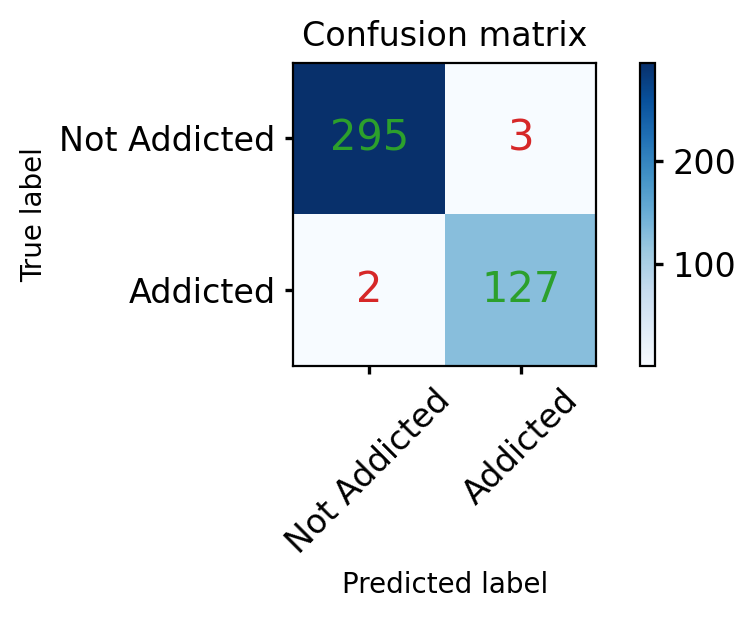

In [1458]:
piped_model = make_pipeline(RobustScaler(),svc_model_linear) 
print(piped_model.get_params()) #this shows how we can access parameters both for the scaler and the classifier

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'precision', return_train_score = True)
#print(scores)
print("shuffled stratified k-fold precision test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'recall', return_train_score = True)
print("shuffled stratified k-fold recall test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

y_pred = cross_val_predict(piped_model, final_features, targets, cv = cv)
print(metrics.classification_report(targets,y_pred,target_names=['Not Addicted','Addicted']))

cm = metrics.confusion_matrix(targets,y_pred)
fig6 = plt.figure()
plot_confusion_matrix(cm, ['Not Addicted','Addicted'])

<Figure size 1000x600 with 0 Axes>

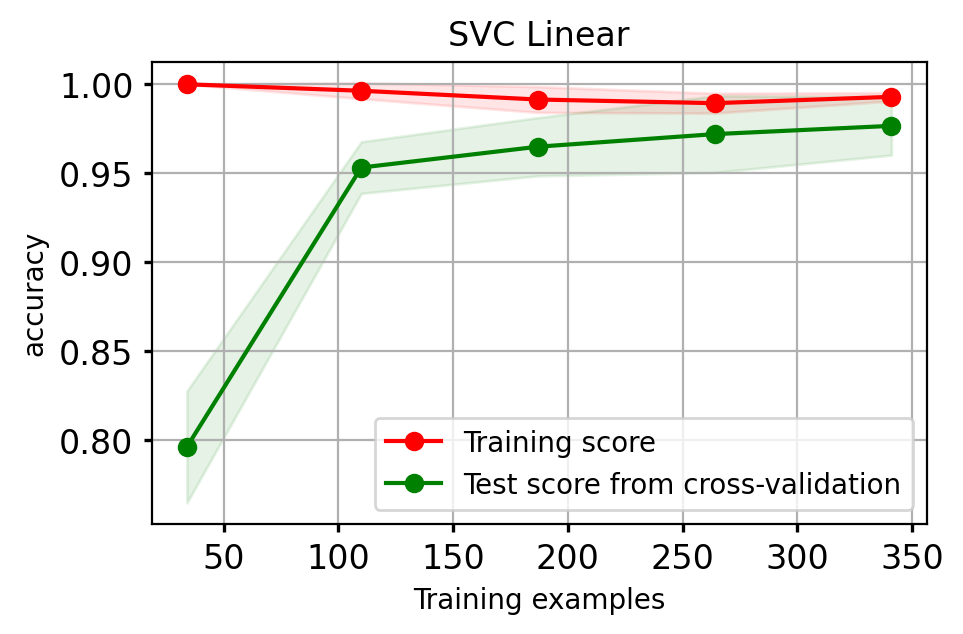

In [1459]:
fig9 = plt.figure()
plot_learning_curve(svc_model_linear, 'SVC Linear', final_features, targets, cv = cv,scoring = 'accuracy');

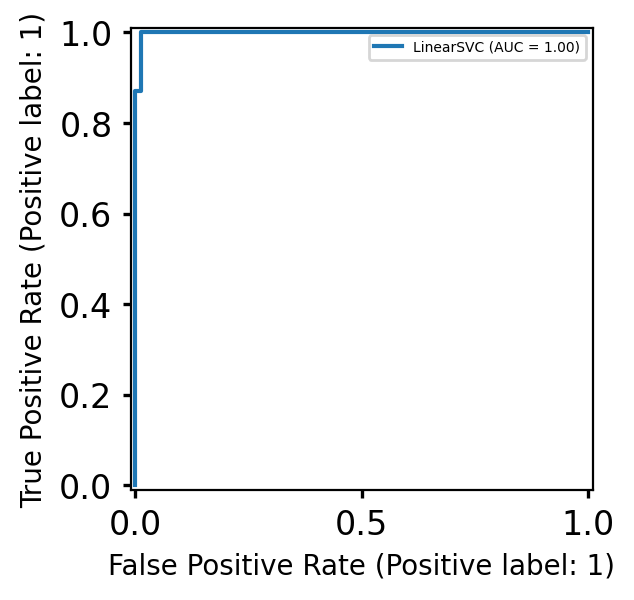

In [1460]:
fig, ax = plt.subplots()
disp = metrics.RocCurveDisplay.from_estimator(svc_model_linear, Xtest, ytest, ax=ax)
disp.ax_.legend(fontsize=5)

## Poly SVC Algorithm

In [1461]:
svc_model_poly = SVC(kernel='poly', degree = 5, class_weight='balanced', probability=True) # runs slow now
svc_model_poly.fit(Xtrain, ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",5
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Scores

In [1462]:
print('train accuracy = ', metrics.accuracy_score(ytrain, svc_model_poly.predict(Xtrain))) #train score
print('test accuracy = ', metrics.accuracy_score(ytest, svc_model_poly.predict(Xtest))) #test score
print('dummy classifier =', metrics.accuracy_score(ytest, np.zeros(len(ytest)))) #performance of a dummy classifier
print('test precision = ', metrics.precision_score(ytest,svc_model_poly.predict(Xtest)))
print('test recall = ', metrics.recall_score(ytest,svc_model_poly.predict(Xtest)))

train accuracy =  0.8125
test accuracy =  0.8411214953271028
dummy classifier = 0.7102803738317757
test precision =  1.0
test recall =  0.45161290322580644


### Pipeline, Cross Validation, Confusion Matrix

{'memory': None, 'steps': [('robustscaler', RobustScaler()), ('svc', SVC(class_weight='balanced', degree=5, kernel='poly', probability=True))], 'transform_input': None, 'verbose': False, 'robustscaler': RobustScaler(), 'svc': SVC(class_weight='balanced', degree=5, kernel='poly', probability=True), 'robustscaler__copy': True, 'robustscaler__quantile_range': (25.0, 75.0), 'robustscaler__unit_variance': False, 'robustscaler__with_centering': True, 'robustscaler__with_scaling': True, 'svc__C': 1.0, 'svc__break_ties': False, 'svc__cache_size': 200, 'svc__class_weight': 'balanced', 'svc__coef0': 0.0, 'svc__decision_function_shape': 'ovr', 'svc__degree': 5, 'svc__gamma': 'scale', 'svc__kernel': 'poly', 'svc__max_iter': -1, 'svc__probability': True, 'svc__random_state': None, 'svc__shrinking': True, 'svc__tol': 0.001, 'svc__verbose': False}
shuffled stratified k-fold precision test = 0.935 , train = 1.000
shuffled stratified k-fold recall test = 0.620 , train = 0.800
              precision   

<Figure size 1000x600 with 0 Axes>

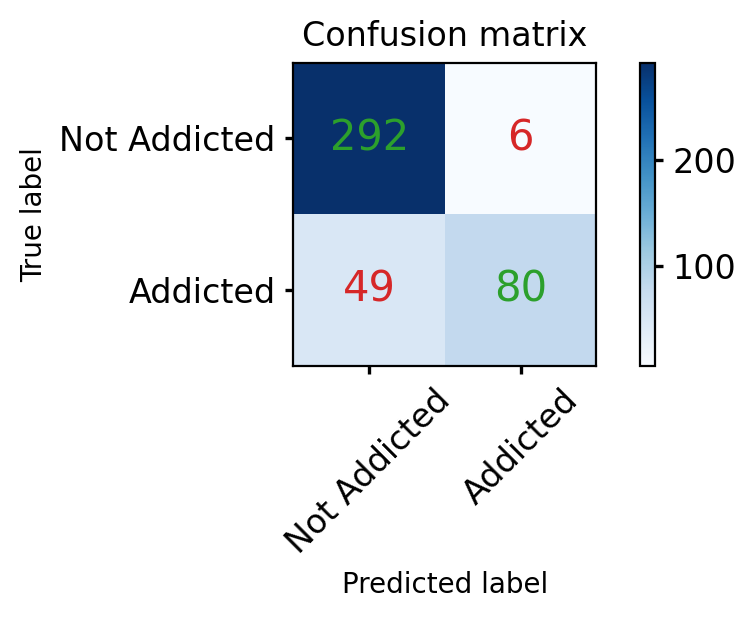

In [1463]:
piped_model = make_pipeline(RobustScaler(),svc_model_poly) 
print(piped_model.get_params()) #this shows how we can access parameters both for the scaler and the classifier

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'precision', return_train_score = True)
#print(scores)
print("shuffled stratified k-fold precision test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'recall', return_train_score = True)
print("shuffled stratified k-fold recall test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

y_pred = cross_val_predict(piped_model, final_features, targets, cv = cv)
print(metrics.classification_report(targets,y_pred,target_names=['Not Addicted','Addicted']))

cm = metrics.confusion_matrix(targets,y_pred)
fig6 = plt.figure()
plot_confusion_matrix(cm, ['Not Addicted','Addicted'])

<Figure size 1000x600 with 0 Axes>

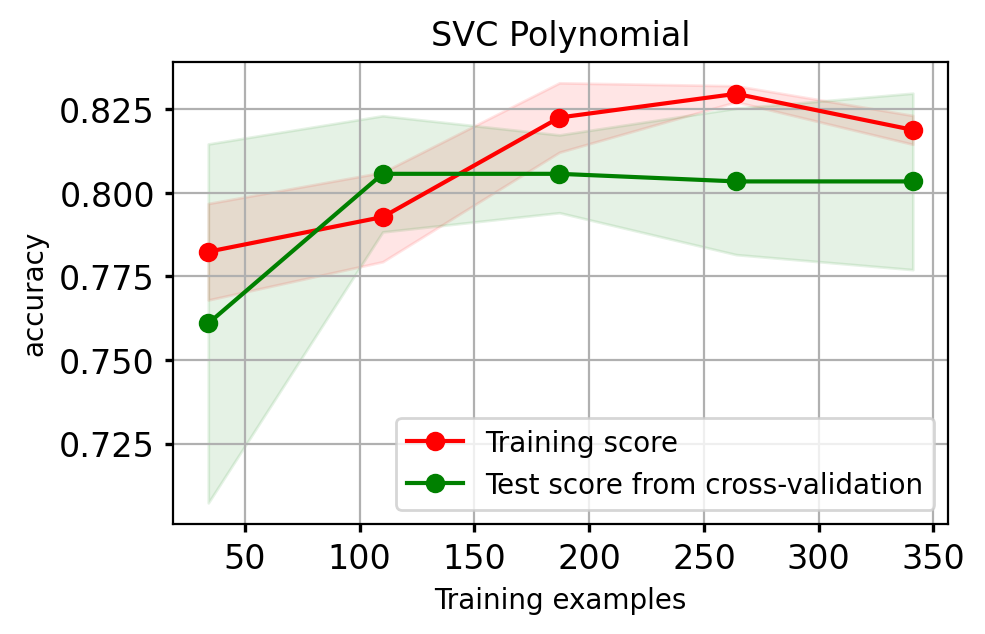

In [1464]:
fig9 = plt.figure()
plot_learning_curve(svc_model_poly, 'SVC Polynomial', final_features, targets, cv = cv,scoring = 'accuracy');

<Figure size 1000x600 with 0 Axes>

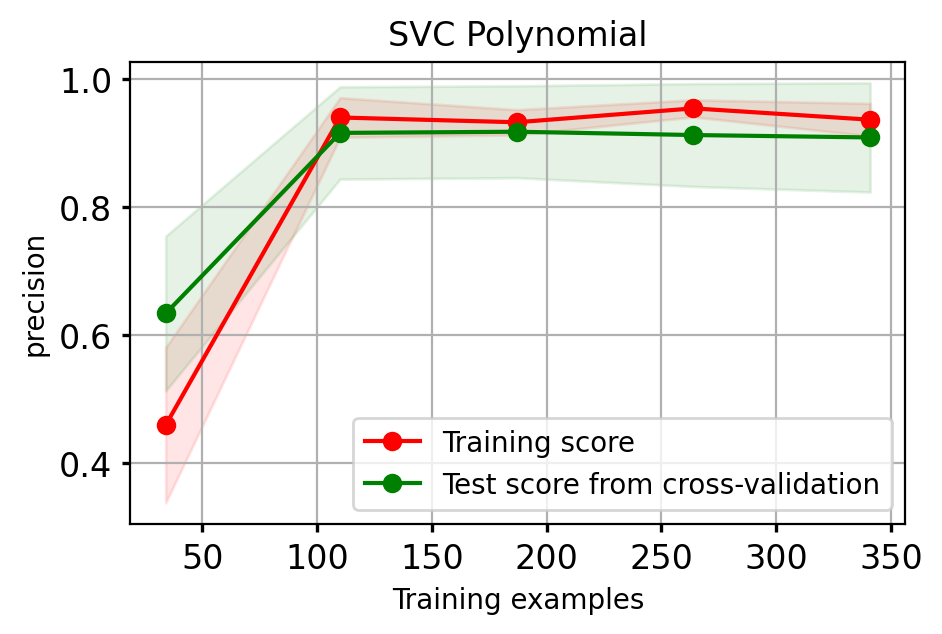

In [1465]:
fig9 = plt.figure()
plot_learning_curve(svc_model_poly, 'SVC Polynomial', final_features, targets, cv = cv,scoring = 'precision');

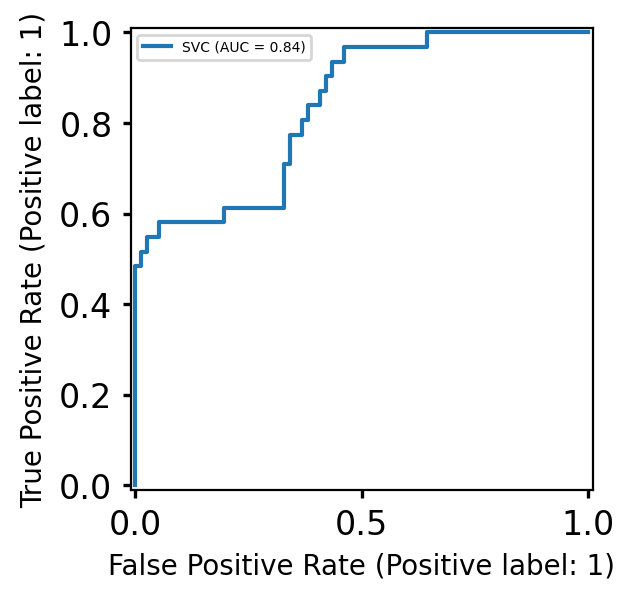

In [1466]:
fig, ax = plt.subplots()
disp = metrics.RocCurveDisplay.from_estimator(svc_model_poly, Xtest, ytest, ax=ax)
disp.ax_.legend(fontsize=5)

## RBF (Radial Basis Function ) SVC Algorithm

In [1467]:
svc_model_rbf = SVC(kernel='rbf', degree = 3, C = 200, gamma = 0.5, class_weight='balanced', probability=True)
svc_model_rbf.fit(Xtrain, ytrain)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",200
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.5
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [1468]:
print('train accuracy = ', metrics.accuracy_score(ytrain, svc_model_rbf.predict(Xtrain))) #train score
print('test accuracy = ', metrics.accuracy_score(ytest, svc_model_rbf.predict(Xtest))) #test score
print('dummy classifier =', metrics.accuracy_score(ytest, np.zeros(len(ytest)))) #performance of a dummy classifier
print('test precision = ', metrics.precision_score(ytest,svc_model_rbf.predict(Xtest)))
print('test recall = ', metrics.recall_score(ytest,svc_model_rbf.predict(Xtest)))

train accuracy =  1.0
test accuracy =  0.7102803738317757
dummy classifier = 0.7102803738317757
test precision =  0.0
test recall =  0.0


c:\Users\Simon Seo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Pipeline, Cross Validation, Confusion Matrix

{'memory': None, 'steps': [('robustscaler', RobustScaler()), ('svc', SVC(C=200, class_weight='balanced', gamma=0.5, probability=True))], 'transform_input': None, 'verbose': False, 'robustscaler': RobustScaler(), 'svc': SVC(C=200, class_weight='balanced', gamma=0.5, probability=True), 'robustscaler__copy': True, 'robustscaler__quantile_range': (25.0, 75.0), 'robustscaler__unit_variance': False, 'robustscaler__with_centering': True, 'robustscaler__with_scaling': True, 'svc__C': 200, 'svc__break_ties': False, 'svc__cache_size': 200, 'svc__class_weight': 'balanced', 'svc__coef0': 0.0, 'svc__decision_function_shape': 'ovr', 'svc__degree': 3, 'svc__gamma': 0.5, 'svc__kernel': 'rbf', 'svc__max_iter': -1, 'svc__probability': True, 'svc__random_state': None, 'svc__shrinking': True, 'svc__tol': 0.001, 'svc__verbose': False}
shuffled stratified k-fold precision test = 0.908 , train = 1.000
shuffled stratified k-fold recall test = 0.449 , train = 1.000
              precision    recall  f1-score  

<Figure size 1000x600 with 0 Axes>

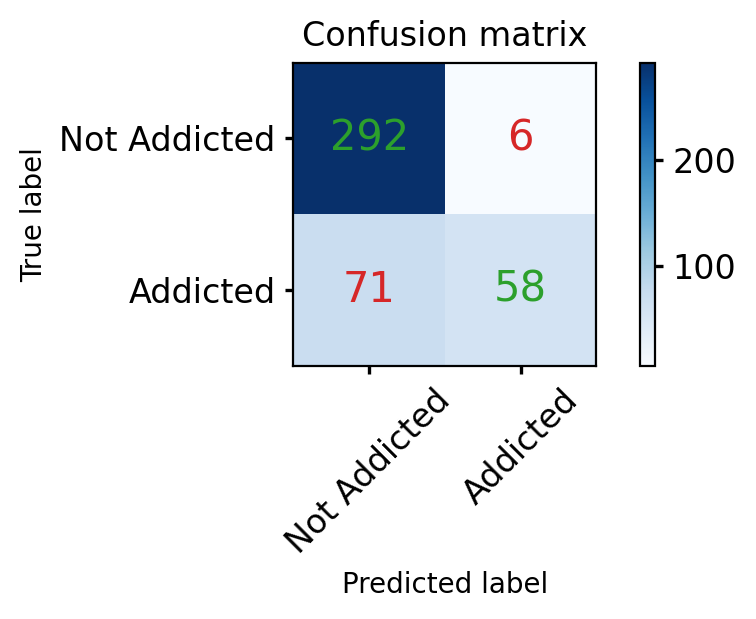

In [1469]:
piped_model = make_pipeline(RobustScaler(),svc_model_rbf) 
print(piped_model.get_params()) #this shows how we can access parameters both for the scaler and the classifier

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'precision', return_train_score = True)
#print(scores)
print("shuffled stratified k-fold precision test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'recall', return_train_score = True)
print("shuffled stratified k-fold recall test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

y_pred = cross_val_predict(piped_model, final_features, targets, cv = cv)
print(metrics.classification_report(targets,y_pred,target_names=['Not Addicted','Addicted']))

cm = metrics.confusion_matrix(targets,y_pred)
fig6 = plt.figure()
plot_confusion_matrix(cm, ['Not Addicted','Addicted'])

<Figure size 1000x600 with 0 Axes>

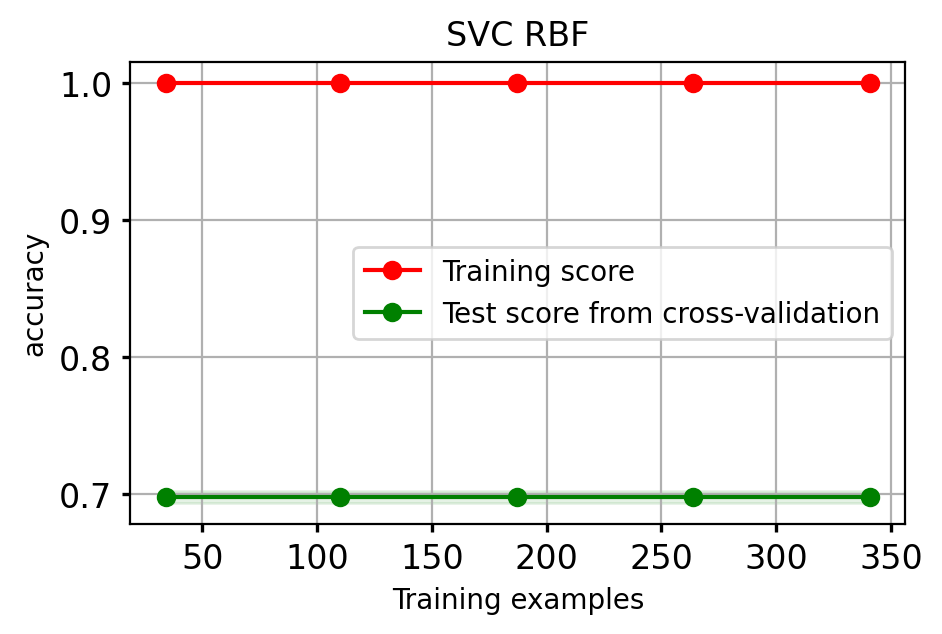

In [1470]:
fig9 = plt.figure()
plot_learning_curve(svc_model_rbf, 'SVC RBF', final_features, targets, cv = cv,scoring = 'accuracy');

### ROC Plot

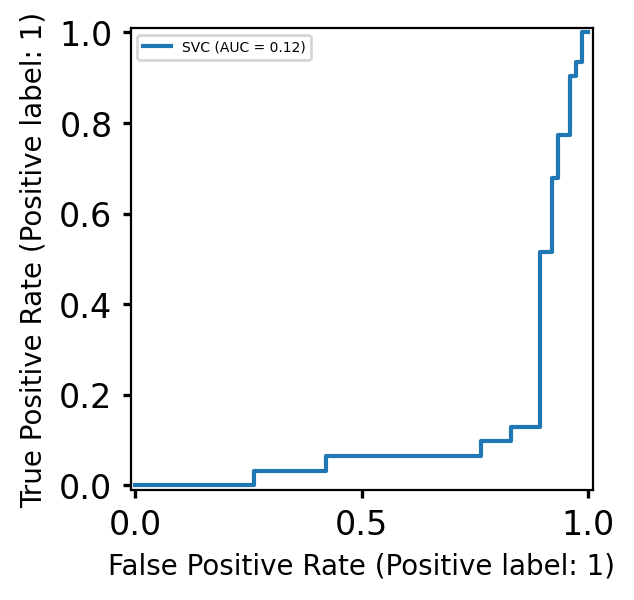

In [1471]:
fig, ax = plt.subplots()
disp = metrics.RocCurveDisplay.from_estimator(svc_model_rbf, Xtest, ytest, ax=ax)
disp.ax_.legend(fontsize=5)

The best result was the linear SVC, so I'm just going to use this.

I think linear is the best because some of the plots I saw had marginal split top and bottom.

I think the poly and rbf were overfitting, therefore high variance.

The ROC and Learning Curves for linear and poly look great. The score is getting closer to 1 and close to each other.

I think variance and bias are balanced. I'm not sure why they're not 1.

The RFB is really bad.

### Optimizing Linear SVC

In [1472]:
best_accuracy = 0
best_precision = 0
best_recall = 0
best_params_acc = {}
best_params_prec = {}
best_params_rec = {}

for c in [0.05, .1, 1, 10, 100, 200]:  # C values to test
    for i in range(1000, 10001, 2000):  # 1000, 3000, 5000, 7000, 9000
        for j in range(1, 100, 10):  # Fewer tol values to test
            tol = j * 0.000001  # Better range: 1e-5 to 1e-3
            
            svc_model_linear = LinearSVC(
                C=c,
                dual=False, 
                tol=tol, 
                max_iter=i, 
                class_weight='balanced',
                random_state=42
            )
            
            svc_model_linear.fit(Xtrain, ytrain)
            ypred = svc_model_linear.predict(Xtest)
            accuracy = metrics.accuracy_score(ytest, ypred)
            recall = metrics.recall_score(ytest, ypred, average='weighted', zero_division=0)
            precision = metrics.precision_score(ytest, ypred, average='weighted', zero_division=0)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params_acc = {'C': c, 'max_iter': i, 'tol': tol}
                
            if recall > best_recall:
                best_recall = recall
                best_params_rec = {'C': c, 'max_iter': i, 'tol': tol}
                
            if precision > best_precision:
                best_precision = precision
                best_params_prec = {'C': c, 'max_iter': i, 'tol': tol}

print("FINAL BEST RESULTS:")
print(f"Best Accuracy: {best_accuracy:.4f} with {best_params_acc}")
print(f"Best Precision: {best_precision:.4f} with {best_params_prec}")
print(f"Best Recall: {best_recall:.4f} with {best_params_rec}")

FINAL BEST RESULTS:
Best Accuracy: 0.9907 with {'C': 0.1, 'max_iter': 1000, 'tol': 1e-06}
Best Precision: 0.9909 with {'C': 0.1, 'max_iter': 1000, 'tol': 1e-06}
Best Recall: 0.9907 with {'C': 0.1, 'max_iter': 1000, 'tol': 1e-06}


In [1473]:
svc_model_linear_final = LinearSVC(
    C=0.1,
    dual=False, 
    tol=1e-6, 
    max_iter=1000, 
    class_weight='balanced',
    random_state=42)

svc_model_linear_final.fit(Xtrain, ytrain)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-06
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo 

In [1474]:
print('train accuracy = ', metrics.accuracy_score(ytrain, svc_model_linear_final.predict(Xtrain))) #train score
print('test accuracy = ', metrics.accuracy_score(ytest, svc_model_linear_final.predict(Xtest))) #test score
print('dummy classifier =', metrics.accuracy_score(ytest, np.zeros(len(ytest)))) #performance of a dummy classifier
print('test precision = ', metrics.precision_score(ytest,svc_model_linear_final.predict(Xtest)))
print('test recall = ', metrics.recall_score(ytest,svc_model_linear_final.predict(Xtest)))

train accuracy =  0.978125
test accuracy =  0.9906542056074766
dummy classifier = 0.7102803738317757
test precision =  0.96875
test recall =  1.0


{'memory': None, 'steps': [('robustscaler', RobustScaler()), ('linearsvc', LinearSVC(C=0.1, class_weight='balanced', dual=False, random_state=42,
          tol=1e-06))], 'transform_input': None, 'verbose': False, 'robustscaler': RobustScaler(), 'linearsvc': LinearSVC(C=0.1, class_weight='balanced', dual=False, random_state=42,
          tol=1e-06), 'robustscaler__copy': True, 'robustscaler__quantile_range': (25.0, 75.0), 'robustscaler__unit_variance': False, 'robustscaler__with_centering': True, 'robustscaler__with_scaling': True, 'linearsvc__C': 0.1, 'linearsvc__class_weight': 'balanced', 'linearsvc__dual': False, 'linearsvc__fit_intercept': True, 'linearsvc__intercept_scaling': 1, 'linearsvc__loss': 'squared_hinge', 'linearsvc__max_iter': 1000, 'linearsvc__multi_class': 'ovr', 'linearsvc__penalty': 'l2', 'linearsvc__random_state': 42, 'linearsvc__tol': 1e-06, 'linearsvc__verbose': 0}
shuffled stratified k-fold precision test = 0.876 , train = 0.909
shuffled stratified k-fold recall t

<Figure size 1000x600 with 0 Axes>

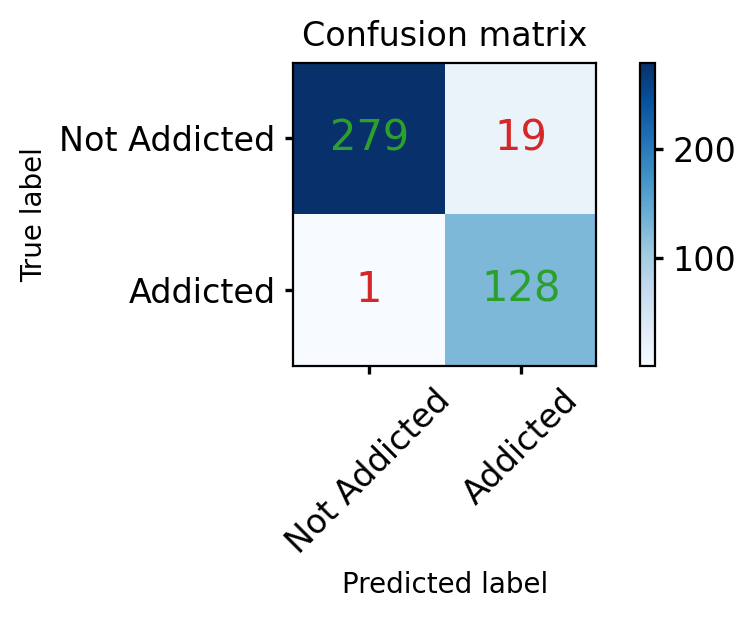

In [1475]:
piped_model = make_pipeline(RobustScaler(),svc_model_linear_final) 
print(piped_model.get_params()) #this shows how we can access parameters both for the scaler and the classifier

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'precision', return_train_score = True)
#print(scores)
print("shuffled stratified k-fold precision test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

scores = cross_validate(piped_model, final_features, targets, cv = cv, scoring = 'recall', return_train_score = True)
print("shuffled stratified k-fold recall test = {:.3f}".format(scores['test_score'].mean()), ", train = {:.3f}".format(scores['train_score'].mean()))

y_pred = cross_val_predict(piped_model, final_features, targets, cv = cv)
print(metrics.classification_report(targets,y_pred,target_names=['Not Addicted','Addicted']))

cm = metrics.confusion_matrix(targets,y_pred)
fig6 = plt.figure()
plot_confusion_matrix(cm, ['Not Addicted','Addicted'])

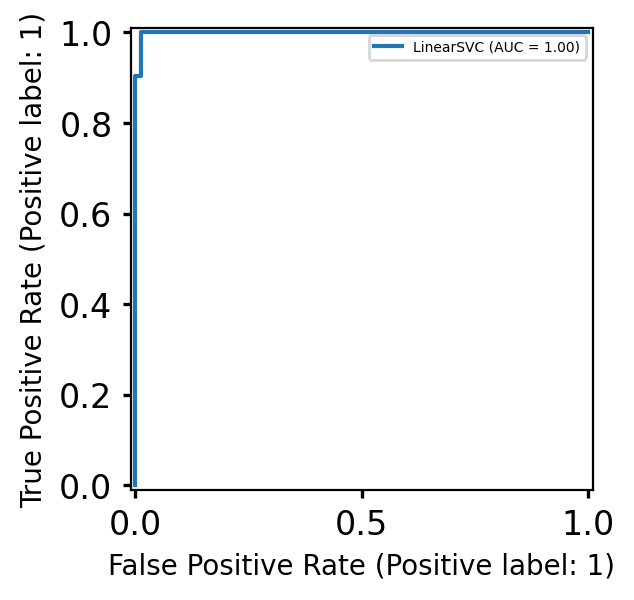

In [1476]:
fig, ax = plt.subplots()
disp = metrics.RocCurveDisplay.from_estimator(svc_model_linear_final, Xtest, ytest, ax=ax)
disp.ax_.legend(fontsize=5)

<Figure size 1000x600 with 0 Axes>

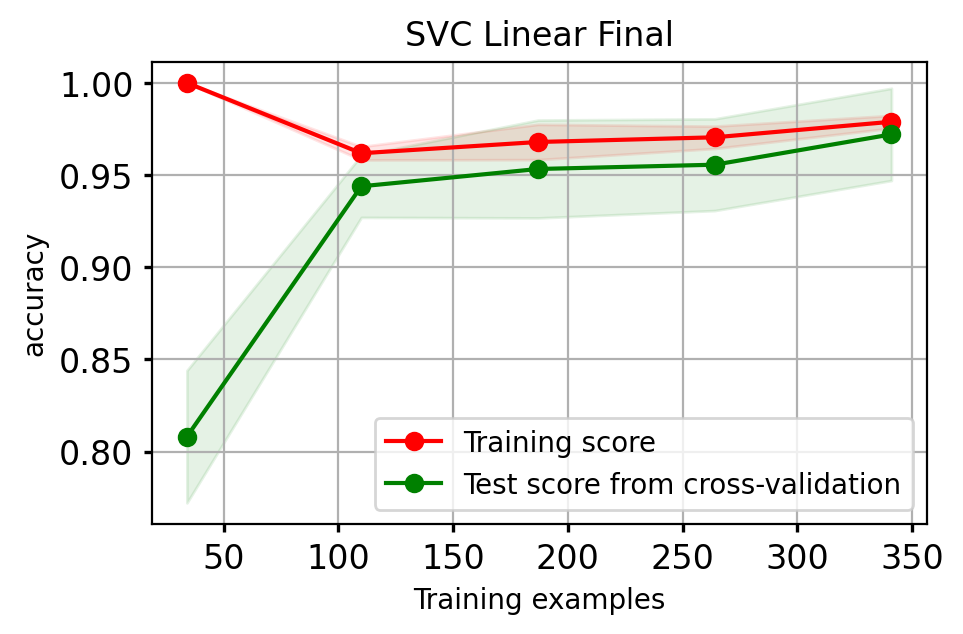

In [1477]:
fig9 = plt.figure()
plot_learning_curve(svc_model_linear_final, 'SVC Linear Final', final_features, targets, cv = cv,scoring = 'accuracy');

<Figure size 1000x600 with 0 Axes>

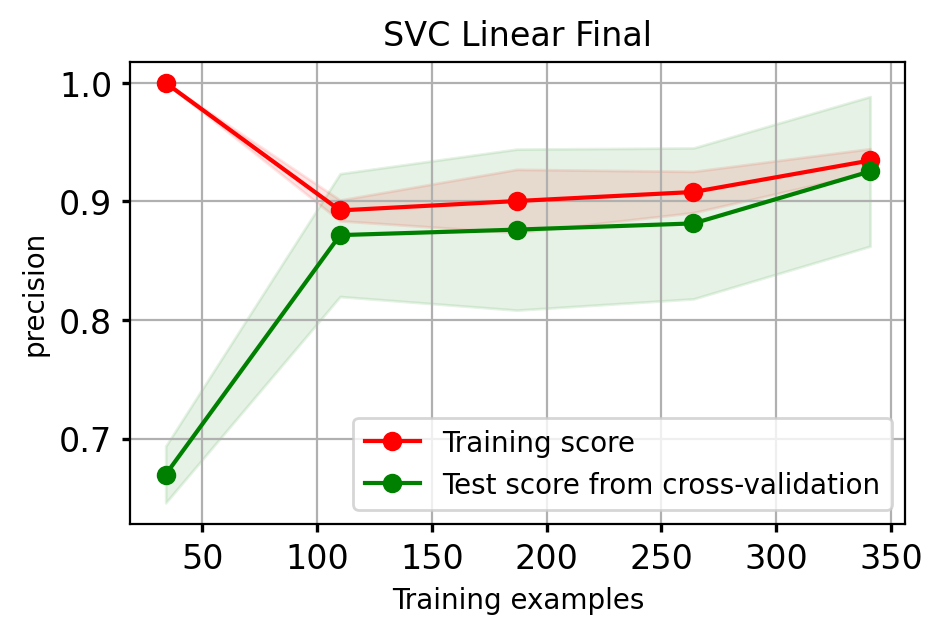

In [1478]:
fig9 = plt.figure()
plot_learning_curve(svc_model_linear_final, 'SVC Linear Final', final_features, targets, cv = cv,scoring = 'precision');

<Figure size 1000x600 with 0 Axes>

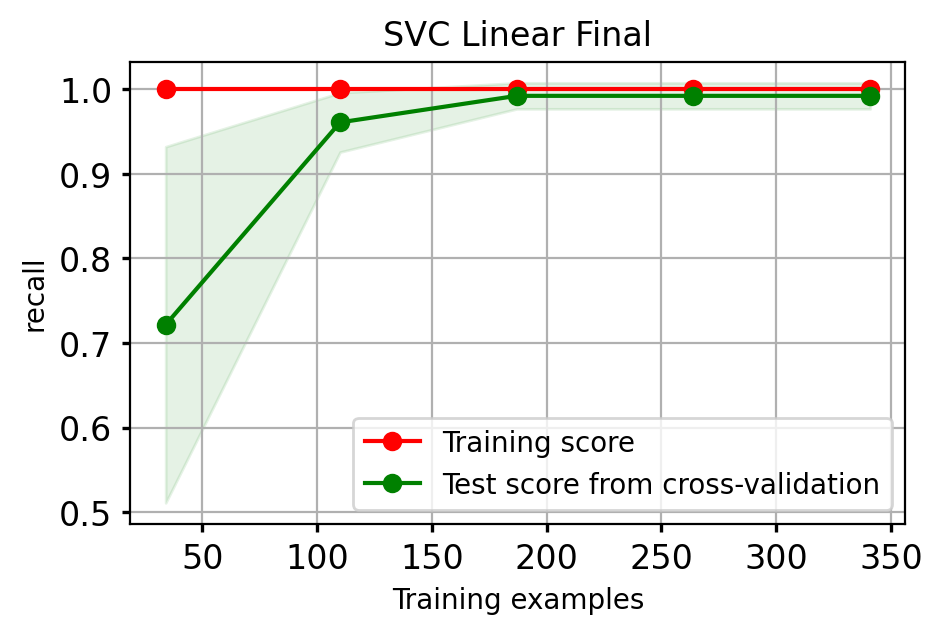

In [1479]:
fig9 = plt.figure()
plot_learning_curve(svc_model_linear_final, 'SVC Linear Final', final_features, targets, cv = cv,scoring = 'recall');

### Grid Search

In [1498]:
piped_model = make_pipeline(RobustScaler(),SVC(random_state=1,kernel='rbf',class_weight='balanced')) 
hyperparameters = {'svc__C': [0.1, 0.25, 1.0, 3.0, 10.0, 20], 'svc__tol': [1e-3,1e-4, 1e-5, 1e-6,1e-7], 'svc__max_iter': [1000, 1500, 3000, 5000]}

model = GridSearchCV(piped_model, hyperparameters, cv = cv, scoring='f1_macro', verbose = 1, n_jobs = 4, return_train_score=True)

model.fit(final_features,targets)

print('Best params, best score:', "{:.4f}".format(model.best_score_), model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params, best score: 0.9728 {'svc__C': 10.0, 'svc__max_iter': 1000, 'svc__tol': 0.001}


## Conclusion

My ROC graph looks very good, and the training scores make it look more plausible except the recall since it's all 1 on the training score.

Maybe I'm making the same mistake I did in previous assignment.

The Grid Search found similar parameters to maximize the scores as my loop.